In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt

### Question 1: Steepest Descent

In [ ]:
def f(x):
    '''
    This is the function we are trying to minimize.
    '''
    x1, x2, x3 = x
    return (x1 + 5)**2 + (x2 + 8)**2 + (x3 + 7)**2 + 2*(x1**2)*(x2**2) + 4*(x1**2)*(x3**2)

def grad(x):
    """
    Each entry is the partial derivative of f with respect to a variable.
    """
    x1, x2, x3 = x
    return np.array([
        2*(x1 + 5) + 4*x1*(x2**2) + 8*x1*(x3**2),
        2*(x2 + 8) + 4*(x1**2)*x2,
        2*(x3 + 7) + 8*(x1**2)*x3
    ], dtype=float)

def hess(x):
    """
    We need to get the Hessian as the second order conditions need the Hessian at the final point.
    """
    x1, x2, x3 = x
    return np.array([
        [2 + 4*(x2**2) + 8*(x3**2), 8*x1*x2, 16*x1*x3],
        [8*x1*x2, 2 + 4*(x1**2), 0],
        [16*x1*x3, 0, 2 + 8*(x1**2)]
    ], dtype=float)


def steepest_descent(x0, tol=1e-6, max_iter=10000):
    """
    1. At iter K, we compute the gradient g_k
    2. We use steepest descent direction d_k = -g_k (the negative of the gradient)
    3. Find the step size alpha_k by line search
    4. Update x(k+1) = x(k) + alpha_k * d_k
    5. Stop when the gradient is far smaller than the tolerance (tol)
    """
    x = np.array(x0, dtype=float)

    xs = [x.copy()]  # The point x recorded at each iteration
    fvals = [f(x)]  # The objective value at each iteration
    grad_norms = [np.linalg.norm(grad(x))]  # The gradient norm at each iteration
    step_sizes = []

    for k in range(max_iter):
        g = grad(x)
        gnorm = np.linalg.norm(g)

        # First-order stopping rule:
        # If the gradient is very small, that means we are near a stationary point
        if gnorm <= tol:
            break
        d = -g    # Descent is negative gradient

        # Exact line search along the current descent direction
        phi = lambda alpha: f(x + alpha * d)  # Define objective function for line search
        result = opt.minimize_scalar(phi, bracket=(0.0, 1.0))  # Find the step size
        alpha = result.x     # The step size

        # Update all the variables
        x = x + alpha * d
        xs.append(x.copy())
        fvals.append(f(x))
        grad_norms.append(np.linalg.norm(grad(x)))
        step_sizes.append(alpha)

    # Once we run through all iterations, or we break early, return
    return {
        "x_star": x,
        "xs": np.array(xs),
        "fvals": np.array(fvals),
        "grad_norms": np.array(grad_norms),
        "step_sizes": np.array(step_sizes)
    }

#### Part a)

In [13]:
x0 = np.array([1.0, 1.0, 1.0])  # Initial point we were given
out = steepest_descent(x0=x0, tol=1e-6)
x_star = out["x_star"]
f_star = f(x_star)
H = hess(x_star)
eigvals = np.linalg.eigvals(H)

print("Initial point x0 =", x0)
print("Final solution x* =", x_star)
print("Final objective f(x*) =", f_star)
print("Iterations =", len(out["fvals"]) - 1)
print("Final gradient norm =", np.linalg.norm(grad(x_star)))

Initial point x0 = [1. 1. 1.]
Final solution x* = [-0.015408   -7.9962033  -6.99335892]
Final objective f(x*) = 24.92301853326727
Iterations = 1898
Final gradient norm = 5.783493836925578e-07


In [15]:
print("\nPart (a): Second-order necessary condition check")
print("Hessian at x* =")
print(H)
print("Eigenvalues of Hessian =", eigvals)

if np.all(eigvals >= -1e-8):
    print("Hessian is positive semidefinite at the final point, meaning that it does satisfy the second-order necessary condition for a minimum.")
else:
    print("Hessian is not positive semidefinite, meaning that it does not satisfy the second-order necessary condition for a minimum.")


Part (a): Second-order necessary condition check
Hessian at x* =
[[649.01362133   0.98564376   1.72405837]
 [  0.98564376   2.00094963   0.        ]
 [  1.72405837   0.           2.00189925]]
Eigenvalues of Hessian = [649.01971678   1.99554021   2.00121321]
Hessian is positive semidefinite at the final point, meaning that it does satisfy the second-order necessary condition for a minimum.


At a stationary point x*, the second order neccessary point requires the hessian of f(x) to be >=0, meaning that it must be semi-definite (all eigenvalues must satisfy lambda_i >= 0 for all i) 

For the Hessian: [649.01971678   1.99554021   2.00121321] all eigenvalues are positive, which implies that the second-order necessary condition is satsified, therefore x* is a local minimum.

#### Part b)

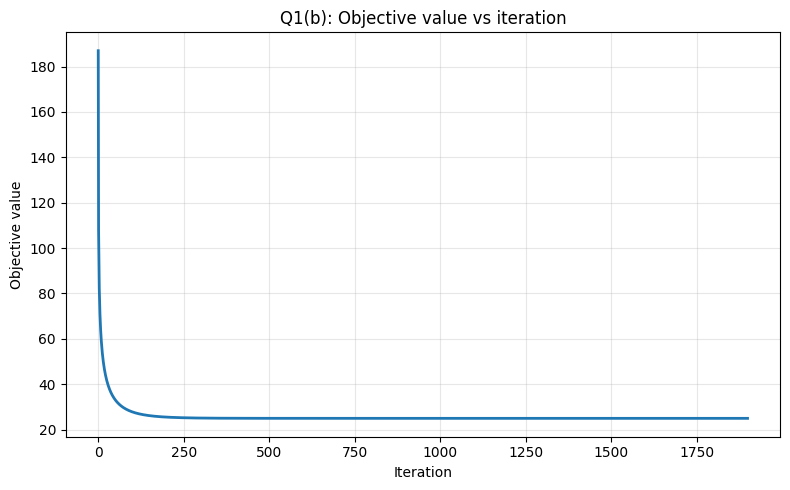

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(out["fvals"])), out["fvals"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Q1(b): Objective value vs iteration")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q1_objective_vs_iteration.png", dpi=200)
plt.show()

#### Part c)

The steepest-descent update that is running is 
[x_(k+1) = x_k - alpha_k( $\nabla$ f(x_k)]
where
alpha_k = arg min f(x_k - alpha( $\nabla$ f(x_k)))
Where alpha_k is chosen by line search using the scipy.optimize.minimize_scalar where we stop when the change magnitude of the gradient is less than the tolerance (10^-6)

From the plot we can observe that f drops quickly during the first 50-150 iterations, and then proceeds to flatten. We do set a max iteration of ten thousand, however our plot converges far earlier. It does not immediately break out of the loop due to the steepest-descent algorithm's instability due to the step size, leading to a fast initial stage, and then a slow final stage of convergence. 